In [32]:
from langchain_openai.chat_models import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import AIMessage, HumanMessage, AnyMessage
from typing import Union

In [33]:
messages: list [Union[AIMessage, HumanMessage]] = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Lance"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Lance

I want to learn about the best place to see Orcas in the US.


In [34]:
load_dotenv()

True

In [35]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [36]:
llm.invoke(messages).pretty_print()

================================== Ai Message ==================================

One of the best places to see orcas (killer whales) in the U.S. is in the waters around the Pacific Northwest, particularly in the San Juan Islands of Washington State. Here are some notable spots:

1. **San Juan Islands, Washington**: These islands are renowned for orca watching, especially in the summer months. The resident pods, particularly the Southern Resident Killer Whales, can often be spotted during this time.

2. **Victoria, British Columbia**: While not in the U.S., Victoria is easily accessible from Washington State and offers excellent whale watching tours that often include orcas.

3. **Johnstone Strait, British Columbia**: Another spot in British Columbia, this area is known for high concentrations of orcas, especially in the late summer.

4. **Maui, Hawaii**: While not as common, transient orcas can sometimes be spotted in Hawaiian waters.

The best time to see orcas in the San Juan Island

In [37]:
def multiply(a: int, b: int) -> int:
    """
    Multiply a and b.
    
    Args:
        a: first int
        b: second int
    """
    return a*b

In [38]:
llm_with_tools = llm.bind_tools([multiply])

In [39]:
tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by 3", name="Lance")])

In [64]:
tool_call

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_GutXUd4Un9Jg3gQIGOx4AWzJ', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 62, 'total_tokens': 79, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': None, 'id': 'chatcmpl-Btbx8Txm4o5VtOqPl5Aj4mr4RbgGx', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--e6410f12-9e4f-4e7d-b17e-81938355eb38-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'call_GutXUd4Un9Jg3gQIGOx4AWzJ', 'type': 'tool_call'}], usage_metadata={'input_tokens': 62, 'output_tokens': 17, 'total_tokens': 79, 'input_token_details': {'audio': 0, 'cache_read': 0}

In [41]:
from typing_extensions import TypedDict

In [42]:
class MessageState(TypedDict):
    messages: list[AnyMessage]

In [ ]:
from typing_extensions import Annotated
from langgraph.graph import add_messages

class MessageState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [45]:
from langgraph.graph import MessagesState

In [47]:
class MessageState(MessagesState):
    pass

In [51]:
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# Test
res = add_messages(initial_messages , new_message)

In [55]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END

In [57]:
def tool_calling_llm(state: MessageState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [59]:
builder = StateGraph(MessageState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)

In [60]:
graph = builder.compile()

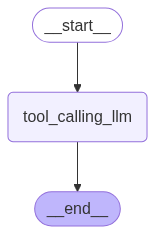

In [61]:
display(Image(graph.get_graph().draw_mermaid_png()))


In [62]:
messages = graph.invoke({"messages": HumanMessage(content="Hello!")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Hello! How can I assist you today?


In [63]:
messages = graph.invoke({"messages": HumanMessage(content="Multiply 2 and 3")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_ILSimM52u1f7wIhWEmVyNav1)
 Call ID: call_ILSimM52u1f7wIhWEmVyNav1
  Args:
    a: 2
    b: 3
